# PHYS 449 - Homework 2, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, September 18, 3:00pm 

*ChatGPT was used to help generate the code and some formulas for the questions*
- - -


2. Produce a dataset $\mathcal{D}$ from your $16 × 16$ Ising Monte Carlo (MC) code. Each element of the dataset is a pair of numbers: the temperature $T_i$ and the corresponding energy $E(T_i)$ of a single MC-sampled configuration in thermal equilibrium. Choose each $T_i$ randomly from the interval $[1.0, 1.5]$, and build a data set of size $|\mathcal{D}| = 10^3$. Divide your dataset into 80% training and 20% validation, and consider linear regression with basis functions that are polynomial in $T$.

Using the given Monte Carlo program for the 2D Ising model, we can easily generate a dataset of 1000 random temperatures from the interval $[1.0, 1.5]$. 

```
Building dataset from equilibrium: 100%|██████████| 1000/1000 [23:31<00:00,  1.41s/it]
Saved dataset to ising_dataset.csv
```

We can now randomly divide the dataset into 80% training and 20% validation using the following code:

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ising_dataset.csv")
print(df.shape)
df.head()

import numpy as np

rng = np.random.default_rng(42)
idx = np.arange(len(df))
rng.shuffle(idx)

cut = int(0.8 * len(df))
train_idx, val_idx = idx[:cut], idx[cut:]

T_train, E_train = df["T"].values[train_idx], df["E"].values[train_idx]
T_val,   E_val   = df["T"].values[val_idx],   df["E"].values[val_idx]

(1000, 2)


(a) Begin with a basis set up to linear order in $T$, and find the regression solution. Calculate the mean squared error (MSE) on both the training and the validation set. Discuss.

In [ ]:
X_train_lin = np.column_stack([np.ones_like(T_train), T_train])
X_val_lin   = np.column_stack([np.ones_like(T_val),   T_val])

w_lin = np.linalg.lstsq(X_train_lin, E_train, rcond=None)[0]
print("Linear weights:", w_lin)

def mse(y, yhat):
    return np.mean((y - yhat)**2)

mse_train_lin = mse(E_train, X_train_lin @ w_lin)
mse_val_lin   = mse(E_val,   X_val_lin   @ w_lin)
print("Linear train MSE:", mse_train_lin)
print("Linear val MSE:", mse_val_lin)

Linear weights: [-2.02910256  0.04487042]
Linear train MSE: 0.003603171771438314
Linear val MSE: 0.004391120898844449


(b) Use your model to extrapolate the energy to $T = 0$. Produce a scatter plot of your datasets and the regression model. Discuss the sources of error in your zero-$T$ prediction.

Linear extrapolation at T=0: -2.0291025600002337


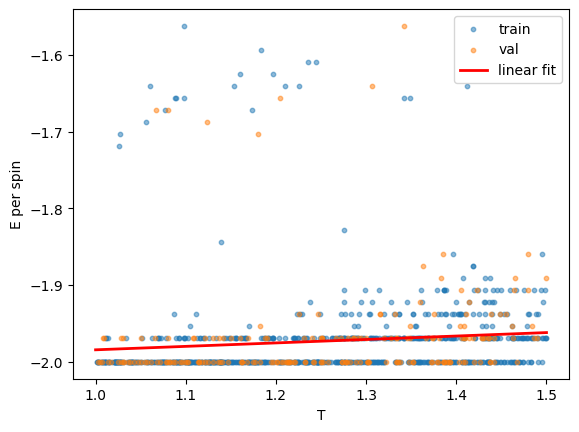

In [45]:
Ehat_T0_lin = w_lin[0]   # intercept
print("Linear extrapolation at T=0:", Ehat_T0_lin)

T_plot = np.linspace(1.0, 1.5, 200)
E_plot_lin = w_lin[0] + w_lin[1]*T_plot

plt.scatter(T_train, E_train, s=10, alpha=0.5, label="train")
plt.scatter(T_val,   E_val,   s=10, alpha=0.5, label="val")
plt.plot(T_plot, E_plot_lin, color="red", lw=2, label="linear fit")
plt.xlabel("T"); plt.ylabel("E per spin")
plt.legend(); plt.show()



(c) Repeat the above steps, now including polynomial basis functions up to $T^2$. Can you interpret the weights of your model?

Quadratic weights: [-2.05963852  0.09440506 -0.01982958]
Quadratic train MSE: 0.0036030445192157014
Quadratic val MSE: 0.004392452117384572
Quadratic extrapolation at T=0: -2.059638518152002


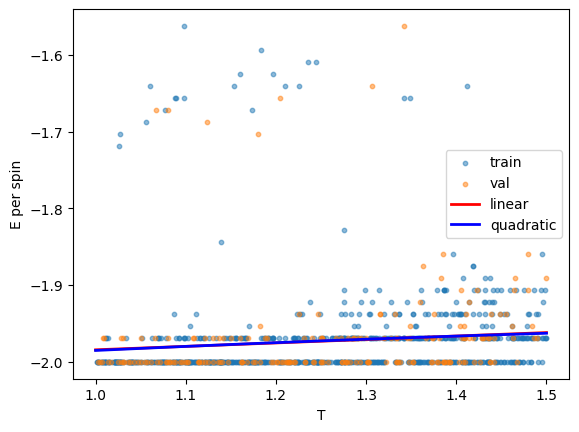

In [46]:
X_train_quad = np.column_stack([np.ones_like(T_train), T_train, T_train**2])
X_val_quad   = np.column_stack([np.ones_like(T_val),   T_val,   T_val**2])

w_quad = np.linalg.lstsq(X_train_quad, E_train, rcond=None)[0]
print("Quadratic weights:", w_quad)

mse_train_quad = mse(E_train, X_train_quad @ w_quad)
mse_val_quad   = mse(E_val,   X_val_quad   @ w_quad)
print("Quadratic train MSE:", mse_train_quad)
print("Quadratic val MSE:", mse_val_quad)

Ehat_T0_quad = w_quad[0]
print("Quadratic extrapolation at T=0:", Ehat_T0_quad)

E_plot_quad = w_quad[0] + w_quad[1]*T_plot + w_quad[2]*T_plot**2

plt.scatter(T_train, E_train, s=10, alpha=0.5, label="train")
plt.scatter(T_val,   E_val,   s=10, alpha=0.5, label="val")
plt.plot(T_plot, E_plot_lin,  color="red",   lw=2, label="linear")
plt.plot(T_plot, E_plot_quad, color="blue",  lw=2, label="quadratic")
plt.xlabel("T"); plt.ylabel("E per spin")
plt.legend(); plt.show()


(d) Discuss the ability of your models to generalize to unseen data. Does improved validation error within the sampled domain correlate with better predictions at $T = 0$?